### ERPAS Analysis

In [69]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.figsize": (10, 5),
    "axes.grid": True,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})

In [70]:
ERPAS_ROOT = Path("/storage/raj.ayush/s2s_final_data/final_iteration/raw/erpas")
FORECAST_ROOT = ERPAS_ROOT / "forecast"
CLIM_ROOT = ERPAS_ROOT / "reforecast" / "climatology"

MANIFEST = Path("/storage/raj.ayush/s2s_final_data/final_iteration/manifests/erpas/google_drive_20260714/inventory.json")

ERPAS_ROOT.exists(), FORECAST_ROOT.exists(), CLIM_ROOT.exists()

(True, True, True)

In [71]:
files = sorted(ERPAS_ROOT.rglob("*"))
files = [p for p in files if p.is_file()]

df = pd.DataFrame({
    "path": [str(p) for p in files],
    "name": [p.name for p in files],
    "size_mb": [p.stat().st_size / 1024**2 for p in files],
    "parent": [p.parent.name for p in files],
    "year": [next((part.replace("annual", "") for part in p.parts if part.startswith("annual")), None) for p in files],
})

df["group"] = np.select(
    [
        df["path"].str.contains("/forecast/"),
        df["path"].str.contains("/reforecast/climatology/")
    ],
    ["forecast", "climatology"],
    default="other"
)

df.head()

,path,name,size_mb,parent,year,group
0,/storage/raj.ayush/s2s_final_data/final_iterat...,gpot_20230104.grb,28.687068,geopotential_height,2023,forecast
1,/storage/raj.ayush/s2s_final_data/final_iterat...,gpot_20230111.grb,28.749209,geopotential_height,2023,forecast
2,/storage/raj.ayush/s2s_final_data/final_iterat...,gpot_20230118.grb,28.655997,geopotential_height,2023,forecast
3,/storage/raj.ayush/s2s_final_data/final_iterat...,gpot_20230125.grb,28.640462,geopotential_height,2023,forecast
4,/storage/raj.ayush/s2s_final_data/final_iterat...,gpot_20230201.grb,28.570553,geopotential_height,2023,forecast


In [72]:
summary = (
    df.groupby(["group", "year", "parent"], dropna=False)
      .agg(files=("path", "count"), size_gb=("size_mb", lambda x: x.sum()/1024))
      .reset_index()
      .sort_values(["group", "year", "parent"])
)

summary

,group,year,parent,files,size_gb
0,climatology,NaN,0101,3,0.032630
1,climatology,NaN,0103,3,0.032888
2,climatology,NaN,0104,3,0.033191
3,climatology,NaN,0108,3,0.032888
4,climatology,NaN,0110,3,0.033229
...,...,...,...,...,...
151,forecast,2024,tp_india_0p5,51,0.079416
152,forecast,2025,geopotential_height,44,1.216627
153,forecast,2025,surface_temperature,44,0.120325
154,forecast,2025,tp,44,0.115617


In [73]:
samples = {}

for year in ["2023", "2024", "2025"]:
    base = FORECAST_ROOT / f"annual{year}"
    samples[(year, "tp")] = sorted((base / "tp").glob("*.grb"))[:3]
    samples[(year, "surface_temperature")] = sorted((base / "surface_temperature").glob("*.grb"))[:3]
    samples[(year, "geopotential_height")] = sorted((base / "geopotential_height").glob("*.grb"))[:3]
    samples[(year, "tp_india_0p5")] = sorted((base / "tp_india_0p5").glob("*.grb"))[:3]

samples

{('2023',
  'tp'): [PosixPath('/storage/raj.ayush/s2s_final_data/final_iteration/raw/erpas/forecast/annual2023/tp/APCP_20230104.grb'), PosixPath('/storage/raj.ayush/s2s_final_data/final_iteration/raw/erpas/forecast/annual2023/tp/APCP_20230111.grb'), PosixPath('/storage/raj.ayush/s2s_final_data/final_iteration/raw/erpas/forecast/annual2023/tp/APCP_20230118.grb')],
 ('2023',
  'surface_temperature'): [PosixPath('/storage/raj.ayush/s2s_final_data/final_iteration/raw/erpas/forecast/annual2023/surface_temperature/tsfc_20230104.grb'), PosixPath('/storage/raj.ayush/s2s_final_data/final_iteration/raw/erpas/forecast/annual2023/surface_temperature/tsfc_20230111.grb'), PosixPath('/storage/raj.ayush/s2s_final_data/final_iteration/raw/erpas/forecast/annual2023/surface_temperature/tsfc_20230118.grb')],
 ('2023',
  'geopotential_height'): [PosixPath('/storage/raj.ayush/s2s_final_data/final_iteration/raw/erpas/forecast/annual2023/geopotential_height/gpot_20230104.grb'), PosixPath('/storage/raj.ayush/s

In [74]:
sample_file = samples[("2023", "tp")][0]
sample_file

PosixPath('/storage/raj.ayush/s2s_final_data/final_iteration/raw/erpas/forecast/annual2023/tp/APCP_20230104.grb')

In [75]:
# Requires cfgrib/eccodes.
# If missing, install in your env:
# conda install -c conda-forge cfgrib eccodes xarray netcdf4 cartopy

import cfgrib

datasets = cfgrib.open_datasets(str(sample_file))
len(datasets), datasets

(1,
 [<xarray.Dataset> Size: 9MB
  Dimensions:     (step: 33, latitude: 181, longitude: 360)
  Coordinates:
    * step        (step) timedelta64[ns] 264B 1 days 2 days ... 32 days 33 days
      valid_time  (step) datetime64[ns] 264B ...
    * latitude    (latitude) float64 1kB 90.0 89.0 88.0 87.0 ... -88.0 -89.0 -90.0
    * longitude   (longitude) float64 3kB 0.0 1.0 2.0 3.0 ... 357.0 358.0 359.0
      time        datetime64[ns] 8B 2023-01-04
      surface     float64 8B 0.0
  Data variables:
      tp          (step, latitude, longitude) float32 9MB ...
  Attributes:
      GRIB_edition:            2
      GRIB_centre:             kwbc
      GRIB_centreDescription:  US National Weather Service - NCEP
      GRIB_subCentre:          0
      Conventions:             CF-1.7
      institution:             US National Weather Service - NCEP])

In [76]:
for i, ds in enumerate(datasets):
    print("=" * 80)
    print("DATASET", i)
    print(ds)
    print("coords:", list(ds.coords))
    print("data_vars:", list(ds.data_vars))

DATASET 0
<xarray.Dataset> Size: 9MB
Dimensions:     (step: 33, latitude: 181, longitude: 360)
Coordinates:
  * step        (step) timedelta64[ns] 264B 1 days 2 days ... 32 days 33 days
    valid_time  (step) datetime64[ns] 264B ...
  * latitude    (latitude) float64 1kB 90.0 89.0 88.0 87.0 ... -88.0 -89.0 -90.0
  * longitude   (longitude) float64 3kB 0.0 1.0 2.0 3.0 ... 357.0 358.0 359.0
    time        datetime64[ns] 8B 2023-01-04
    surface     float64 8B 0.0
Data variables:
    tp          (step, latitude, longitude) float32 9MB ...
Attributes:
    GRIB_edition:            2
    GRIB_centre:             kwbc
    GRIB_centreDescription:  US National Weather Service - NCEP
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             US National Weather Service - NCEP
coords: ['time', 'step', 'surface', 'latitude', 'longitude', 'valid_time']
data_vars: ['tp']


In [77]:
def open_grib(path):
    dsets = cfgrib.open_datasets(str(path), backend_kwargs={"indexpath": ""})
    if len(dsets) == 1:
        return dsets[0]
    return xr.merge(dsets, compat="override")

ds = open_grib(sample_file)
ds

<xarray.Dataset> Size: 9MB
Dimensions:     (step: 33, latitude: 181, longitude: 360)
Coordinates:
  * step        (step) timedelta64[ns] 264B 1 days 2 days ... 32 days 33 days
    valid_time  (step) datetime64[ns] 264B ...
  * latitude    (latitude) float64 1kB 90.0 89.0 88.0 87.0 ... -88.0 -89.0 -90.0
  * longitude   (longitude) float64 3kB 0.0 1.0 2.0 3.0 ... 357.0 358.0 359.0
    time        datetime64[ns] 8B 2023-01-04
    surface     float64 8B 0.0
Data variables:
    tp          (step, latitude, longitude) float32 9MB ...
Attributes:
    GRIB_edition:            2
    GRIB_centre:             kwbc
    GRIB_centreDescription:  US National Weather Service - NCEP
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             US National Weather Service - NCEP

In [78]:
print("Dims:")
for k, v in ds.dims.items():
    print(k, v)

print("\nCoords:")
for c in ds.coords:
    print(c, ds[c].shape, ds[c].attrs)

print("\nVariables:")
for v in ds.data_vars:
    print(v, ds[v].shape, ds[v].attrs)

Dims:
step 33
latitude 181
longitude 360

Coords:
time () {'long_name': 'initial time of forecast', 'standard_name': 'forecast_reference_time'}
step (33,) {'long_name': 'time since forecast_reference_time', 'standard_name': 'forecast_period'}
surface () {'long_name': 'original GRIB coordinate for key: level(surface)', 'units': '1'}
latitude (181,) {'units': 'degrees_north', 'standard_name': 'latitude', 'long_name': 'latitude', 'stored_direction': 'decreasing'}
longitude (360,) {'units': 'degrees_east', 'standard_name': 'longitude', 'long_name': 'longitude'}
valid_time (33,) {'standard_name': 'time', 'long_name': 'time'}

Variables:
tp (33, 181, 360) {'GRIB_paramId': 228228, 'GRIB_dataType': 'fc', 'GRIB_numberOfPoints': 65160, 'GRIB_typeOfLevel': 'surface', 'GRIB_stepUnits': 1, 'GRIB_stepType': 'accum', 'GRIB_gridType': 'regular_ll', 'GRIB_uvRelativeToGrid': 0, 'GRIB_NV': 0, 'GRIB_Nx': 360, 'GRIB_Ny': 181, 'GRIB_cfName': 'unknown', 'GRIB_cfVarName': 'tp', 'GRIB_gridDefinitionDescription

/home/raj.ayush/.vscode-server/tmp/ipykernel_267614/241844882.py:2: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  for k, v in ds.dims.items():
<frozen _collections_abc>:861: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.


In [79]:
def grid_report(ds):
    lat_name = "latitude" if "latitude" in ds.coords else "lat"
    lon_name = "longitude" if "longitude" in ds.coords else "lon"

    lat = ds[lat_name].values
    lon = ds[lon_name].values

    dlat = np.unique(np.round(np.abs(np.diff(lat)), 6))
    dlon = np.unique(np.round(np.abs(np.diff(lon)), 6))

    return {
        "lat_name": lat_name,
        "lon_name": lon_name,
        "lat_min": float(np.nanmin(lat)),
        "lat_max": float(np.nanmax(lat)),
        "lon_min": float(np.nanmin(lon)),
        "lon_max": float(np.nanmax(lon)),
        "nlat": lat.size,
        "nlon": lon.size,
        "dlat_unique": dlat[:10],
        "dlon_unique": dlon[:10],
    }

grid_report(ds)

{'lat_name': 'latitude',
 'lon_name': 'longitude',
 'lat_min': -90.0,
 'lat_max': 90.0,
 'lon_min': 0.0,
 'lon_max': 359.0,
 'nlat': 181,
 'nlon': 360,
 'dlat_unique': array([1.]),
 'dlon_unique': array([1.])}

In [80]:
var = list(ds.data_vars)[0]
da = ds[var]
da

<xarray.DataArray 'tp' (step: 33, latitude: 181, longitude: 360)> Size: 9MB
[2150280 values with dtype=float32]
Coordinates:
  * step        (step) timedelta64[ns] 264B 1 days 2 days ... 32 days 33 days
    valid_time  (step) datetime64[ns] 264B ...
  * latitude    (latitude) float64 1kB 90.0 89.0 88.0 87.0 ... -88.0 -89.0 -90.0
  * longitude   (longitude) float64 3kB 0.0 1.0 2.0 3.0 ... 357.0 358.0 359.0
    time        datetime64[ns] 8B 2023-01-04
    surface     float64 8B 0.0
Attributes: (12/31)
    GRIB_paramId:                             228228
    GRIB_dataType:                            fc
    GRIB_numberOfPoints:                      65160
    GRIB_typeOfLevel:                         surface
    GRIB_stepUnits:                           1
    GRIB_stepType:                            accum
    ...                                       ...
    GRIB_shortName:                           tp
    GRIB_totalNumber:                         4
    GRIB_units:                               kg m**-2
    long_name:                                Total Precipitation
    units:                                    kg m**-2
    standard_name:                            unknown

NameError: name 'plot_da' is not defined

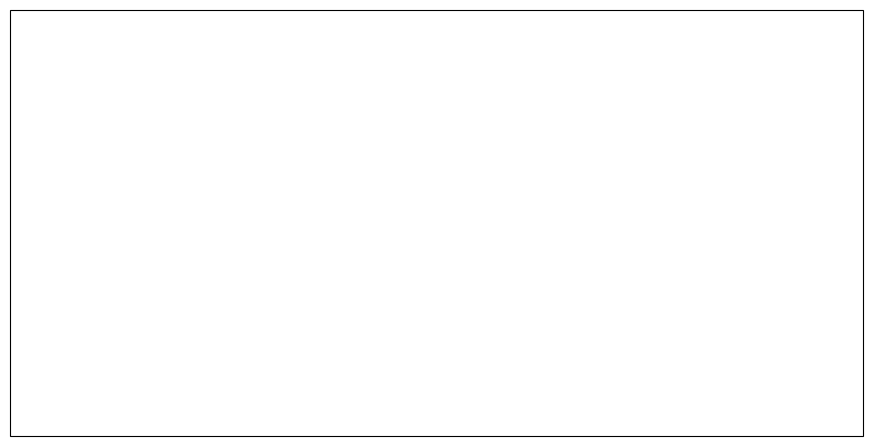

In [81]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature

fig = plt.figure(figsize=(11, 6))
ax = plt.axes(projection=ccrs.PlateCarree())

plot_da.plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap="turbo",
    cbar_kwargs={"label": f"{var} ({da.attrs.get('units', '')})"}
)

ax.coastlines(linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linewidth=0.5)
ax.set_title(f"ERPAS {var} | {sample_file.name}")
plt.show()

In [ ]:
records = []

for p in sorted(FORECAST_ROOT.rglob("*.grb")):
    try:
        dsi = open_grib(p)
        records.append({
            "file": str(p),
            "name": p.name,
            "year": next((part.replace("annual", "") for part in p.parts if part.startswith("annual")), None),
            "folder": p.parent.name,
            "vars": ",".join(dsi.data_vars),
            "dims": dict(dsi.dims),
            "coords": ",".join(dsi.coords),
            "size_mb": p.stat().st_size / 1024**2,
        })
    except Exception as e:
        records.append({
            "file": str(p),
            "name": p.name,
            "folder": p.parent.name,
            "error": repr(e),
        })

meta = pd.DataFrame(records)
meta.head()

/home/raj.ayush/.vscode-server/tmp/ipykernel_267614/4068738841.py:12: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  "dims": dict(dsi.dims),
/home/raj.ayush/.vscode-server/tmp/ipykernel_267614/4068738841.py:12: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  "dims": dict(dsi.dims),
/home/raj.ayush/.vscode-server/tmp/ipykernel_267614/4068738841.py:12: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.


,file,name,year,folder,vars,dims,coords,size_mb
0,/storage/raj.ayush/s2s_final_data/final_iterat...,gpot_20230104.grb,2023,geopotential_height,gh,"{'step': 33, 'isobaricInhPa': 7, 'latitude': 1...","time,step,isobaricInhPa,latitude,longitude,val...",28.687068
1,/storage/raj.ayush/s2s_final_data/final_iterat...,gpot_20230111.grb,2023,geopotential_height,gh,"{'step': 33, 'isobaricInhPa': 7, 'latitude': 1...","time,step,isobaricInhPa,latitude,longitude,val...",28.749209
2,/storage/raj.ayush/s2s_final_data/final_iterat...,gpot_20230118.grb,2023,geopotential_height,gh,"{'step': 33, 'isobaricInhPa': 7, 'latitude': 1...","time,step,isobaricInhPa,latitude,longitude,val...",28.655997
3,/storage/raj.ayush/s2s_final_data/final_iterat...,gpot_20230125.grb,2023,geopotential_height,gh,"{'step': 33, 'isobaricInhPa': 7, 'latitude': 1...","time,step,isobaricInhPa,latitude,longitude,val...",28.640462
4,/storage/raj.ayush/s2s_final_data/final_iterat...,gpot_20230201.grb,2023,geopotential_height,gh,"{'step': 33, 'isobaricInhPa': 7, 'latitude': 1...","time,step,isobaricInhPa,latitude,longitude,val...",28.570553


In [ ]:
def describe_forecast_structure(ds):
    likely_ensemble = [d for d in ds.dims if d.lower() in ["number", "member", "ensemble", "realization"]]
    likely_lead = [d for d in ds.dims if d.lower() in ["step", "leadtime", "lead_time", "time"]]

    print("Likely ensemble dims:", likely_ensemble)
    print("Likely lead/time dims:", likely_lead)

    for c in ds.coords:
        vals = ds[c].values
        print("\n", c, ds[c].dims, ds[c].shape)
        print(vals[:10] if vals.size > 10 else vals)

describe_forecast_structure(ds)

Likely ensemble dims: []
Likely lead/time dims: ['step']

 time () ()
2023-01-04T00:00:00.000000000

 step ('step',) (33,)
[ 86400000000000 172800000000000 259200000000000 345600000000000
 432000000000000 518400000000000 604800000000000 691200000000000
 777600000000000 864000000000000]

 surface () ()
0.0

 latitude ('latitude',) (181,)
[90. 89. 88. 87. 86. 85. 84. 83. 82. 81.]

 longitude ('longitude',) (360,)
[0. 1. 2. 3. 4. 5. 6. 7. 8. 9.]

 valid_time ('step',) (33,)
['2023-01-05T00:00:00.000000000' '2023-01-06T00:00:00.000000000'
 '2023-01-07T00:00:00.000000000' '2023-01-08T00:00:00.000000000'
 '2023-01-09T00:00:00.000000000' '2023-01-10T00:00:00.000000000'
 '2023-01-11T00:00:00.000000000' '2023-01-12T00:00:00.000000000'
 '2023-01-13T00:00:00.000000000' '2023-01-14T00:00:00.000000000']


In [ ]:
ERA5_PATH = Path("/storage/raj.ayush/s2s_final_data/final_iteration/raw/era5/YOUR_FILE.nc")
IMD_PATH = Path("/storage/raj.ayush/s2s_final_data/final_iteration/raw/imd/YOUR_FILE.nc")

# era5 = xr.open_dataset(ERA5_PATH)
# imd = xr.open_dataset(IMD_PATH)